# Non-new complex rules across stages — eligible FOVs


## Imports


In [1]:
import os
import sys
import warnings

from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
sys.path[:0] = [os.path.abspath(".."), os.path.abspath("../..")]

import data_helper as dh
import vis_helper as vh
import complex_stages_helper as stage
import complex_stages_vis as vis


## Parameters


In [2]:
RULE_MAX_ITEMS = 4
KINDS = ["attracts", "avoids"]
MAX_FDR = 0.05
STRENGTH_METRIC = "Lift"

SCORE_COLUMN = "Pathological score"
STAGES = ["Control", "Mild", "Severe"]
ORGANS = ["Colon", "Duodenum"]

USE_CELL_ELIGIBILITY = True
MIN_CELLS_PER_TYPE = 20
MIN_RULE_FOVS = 5
TOP_RULES = 12
DETAIL_RULES = 2

TEX_RULE_EXPORTS = {
    ("attracts", "Colon", "Goblet, Macrophage -> Epithelial, Plasma"): {
        "availability": "complex_nonnew_goblet_macrophage_epithelial_plasma_availability.png",
        "strength": "complex_nonnew_eligible_goblet_macrophage_epithelial_plasma_strength.png",
        "fovs": "complex_nonnew_eligible_goblet_macrophage_epithelial_plasma_fovs.png",
    },
    ("attracts", "Colon", "Endothelial, Epithelial -> Goblet, SMV"): {
        "availability": "complex_endothelial_epithelial_goblet_smv_availability.png",
        "strength": "complex_eligible_endothelial_epithelial_goblet_smv_strength.png",
        "fovs": "complex_eligible_endothelial_epithelial_goblet_smv_fovs.png",
    },
    ("avoids", "Duodenum", "Goblet -> CD8T, Macrophage"): {
        "availability": "complex_goblet_cd8t_macrophage_availability.png",
        "strength": "complex_eligible_goblet_avoids_cd8t_macrophage_strength.png",
        "fovs": "complex_eligible_goblet_avoids_cd8t_macrophage_fovs.png",
    },
    ("attracts", "Colon", "Epithelial, Neuron -> Goblet, Macrophage"): {
        "strength": "complex_opposite_epithelial_neuron_goblet_macrophage_strength.png",
    },
    ("avoids", "Duodenum", "Muscle -> CD8T, Fibroblast"): {
        "strength": "complex_eligible_muscle_avoids_cd8t_fibroblast_strength.png",
        "fovs": "complex_eligible_muscle_avoids_cd8t_fibroblast_fovs.png",
    },
    ("avoids", "Duodenum", "Muscle -> Plasma, SMV"): {
        "strength": "complex_eligible_muscle_avoids_plasma_smv_strength.png",
    },
}

TEX_OVERVIEW_EXPORTS = {
    ("attracts", "Colon"): "complex_eligible_colon_attracts_overview.png",
    ("avoids", "Duodenum"): "complex_eligible_duodenum_avoids_overview.png",
}


## Data loading


In [3]:
df_cells, df_fovs, df_biopsy = dh.load_spatial_data()
df_results = dh.load_results(
    rule_max_items=RULE_MAX_ITEMS,
    kind=None,
    max_fdr=1.0,
    informative_only=False,
)
all_rules = stage.prepare_rules(df_results, df_fovs)


Dropped 21 FOVs: Control_S


Loaded 598093 cells; FOVs: 267, biopsies: 73, patients: 71


Read results_CN_pairwise.csv + results_CN_complex.csv
Loaded 1190114 rules.


Kept 1190114 rules at FDR <= 1.0.


Kept 1172931 rules naming no Unidentified.


Kept 1172931 rules (max_items=4, kind=None).


## Short analysis functions


In [4]:
def strength_label(kind):
    return STRENGTH_METRIC


def scope_label(kind):
    denominator = (
        f"{MIN_CELLS_PER_TYPE}+ cells per rule cell type"
        if USE_CELL_ELIGIBILITY else "all FOVs"
    )
    return " · ".join([
        kind,
        "non-new complex rules",
        f"stage column: {SCORE_COLUMN}",
        f"FDR <= {MAX_FDR}",
        denominator,
        f"at least {MIN_RULE_FOVS} rule FOVs in one stage",
    ])


## Results


In [5]:
vis.clear_exports([
    *TEX_OVERVIEW_EXPORTS.values(),
    *[
        filename
        for rule_exports in TEX_RULE_EXPORTS.values()
        for filename in rule_exports.values()
    ],
])

def show_kind(kind):
    display(Markdown(f"## {kind.title()}"))
    kind_rules = all_rules[all_rules["Kind"] == kind].copy()
    complex_rules = stage.select_complex_rules(
        kind_rules,
        max_fdr=MAX_FDR,
        new_only=False,
        min_strength=1.0,
        metric=STRENGTH_METRIC,
    )
    eligibility = stage.rule_eligibility(
        complex_rules, df_cells, MIN_CELLS_PER_TYPE
    )

    for organ in ORGANS:
        display(Markdown(f"### {organ}"))
        prevalence = stage.stage_prevalence(
            complex_rules,
            kind_rules,
            eligibility,
            df_fovs,
            organ,
            STAGES,
            SCORE_COLUMN,
            MAX_FDR,
            USE_CELL_ELIGIBILITY,
        )
        top, ranked_names = stage.rank_rules(
            prevalence, STAGES, MIN_RULE_FOVS, TOP_RULES
        )
        display(stage.result_table(top, new_only=False))
        vis.plot_prevalence_overview(
            top,
            STAGES,
            organ=organ,
            params=scope_label(kind),
            save=TEX_OVERVIEW_EXPORTS.get((kind, organ)),
        )

        chosen = stage.detail_rules(
            complex_rules, ranked_names, DETAIL_RULES, new_only=False
        )
        report_rules = [
            rule
            for export_kind, export_organ, rule in TEX_RULE_EXPORTS
            if export_kind == kind and export_organ == organ and rule in ranked_names
        ]
        chosen = list(dict.fromkeys(chosen + report_rules))
        for name in chosen:
            export = TEX_RULE_EXPORTS.get((kind, organ, name), {})
            rule_prevalence = top[top["name"].astype(str) == name].copy()
            if export.get("availability"):
                availability = stage.availability_breakdown(
                    [name], complex_rules, kind_rules, eligibility, df_fovs,
                    organ, STAGES, SCORE_COLUMN, MAX_FDR,
                )
                vis.plot_availability_breakdown(
                    availability, STAGES, [name], organ=organ,
                    params=scope_label(kind), save=export["availability"],
                )
            strengths = stage.patient_strengths(
                name,
                complex_rules,
                kind_rules,
                eligibility,
                df_fovs,
                organ,
                STAGES,
                SCORE_COLUMN,
                STRENGTH_METRIC,
                USE_CELL_ELIGIBILITY,
            )
            vis.plot_prevalence_and_strength(
                rule_prevalence,
                strengths,
                STAGES,
                metric=strength_label(kind),
                organ=organ,
                params=scope_label(kind),
                new_only=False,
                save=export.get("strength"),
            )
            examples = stage.fov_examples(
                name,
                complex_rules,
                kind_rules,
                eligibility,
                df_fovs,
                organ,
                STAGES,
                SCORE_COLUMN,
                STRENGTH_METRIC,
                USE_CELL_ELIGIBILITY,
                new_only=False,
            )
            vh.plot_stage_rule_fovs(
                examples,
                STAGES,
                df_cells,
                df_fovs,
                organ=organ,
                subtitle="Complex rule and strongest simpler rule",
                params=scope_label(kind),
                cell_size=11,
                save=export.get("fovs"),
            )


## Attractions


## Attracts

### Colon

,name,stage,complex prevalence,simpler prevalence
4428,"Endothelial, Epithelial -> Goblet, SMV",Control,2 / 15 (13%),14 / 15 (93%)
4429,"Endothelial, Epithelial -> Goblet, SMV",Mild,1 / 9 (11%),9 / 9 (100%)
4430,"Endothelial, Epithelial -> Goblet, SMV",Severe,6 / 10 (60%),9 / 10 (90%)
738,"Goblet, Macrophage -> Epithelial, Plasma",Control,12 / 25 (48%),23 / 25 (92%)
739,"Goblet, Macrophage -> Epithelial, Plasma",Mild,1 / 12 (8%),7 / 12 (58%)
740,"Goblet, Macrophage -> Epithelial, Plasma",Severe,3 / 14 (21%),11 / 14 (79%)
2154,"Epithelial, Neuron -> Goblet, Macrophage",Control,2 / 14 (14%),14 / 14 (100%)
2155,"Epithelial, Neuron -> Goblet, Macrophage",Mild,13 / 25 (52%),23 / 25 (92%)
2156,"Epithelial, Neuron -> Goblet, Macrophage",Severe,5 / 16 (31%),15 / 16 (94%)
2001,"Epithelial, SMV -> Goblet, Plasma",Control,7 / 21 (33%),20 / 21 (95%)


saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_eligible_colon_attracts_overview.png


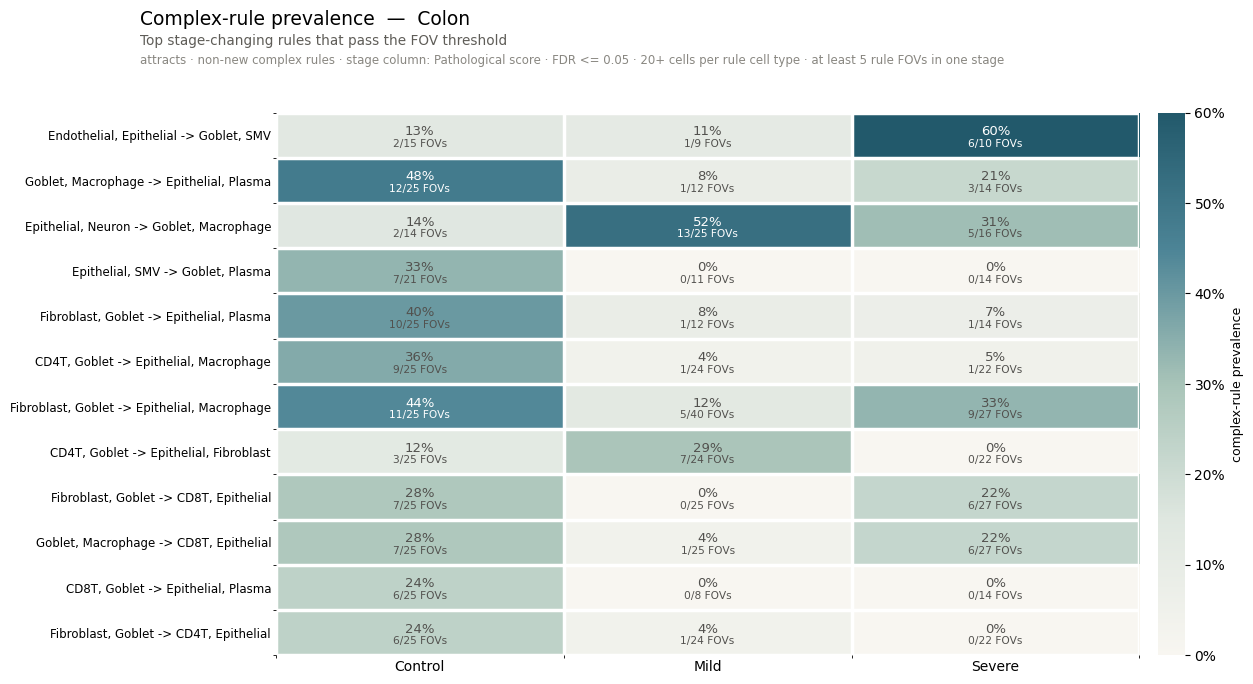

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_endothelial_epithelial_goblet_smv_availability.png


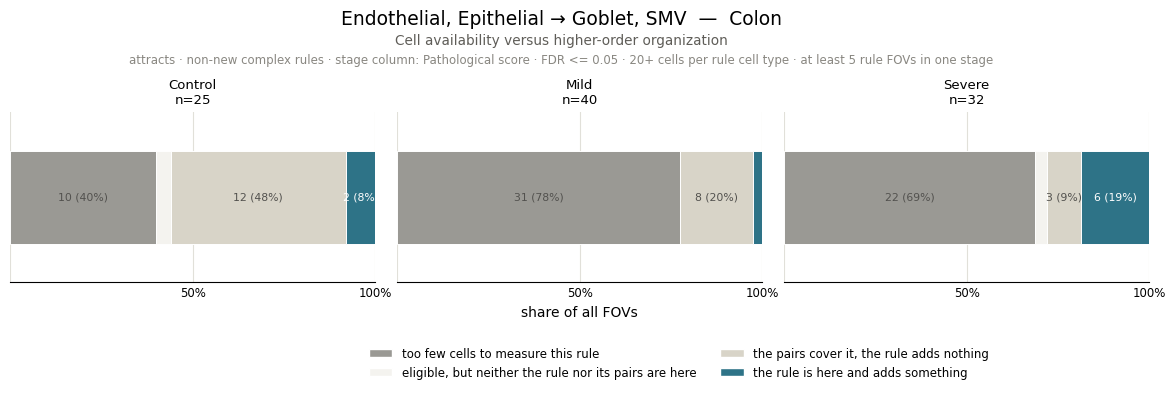

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_eligible_endothelial_epithelial_goblet_smv_strength.png


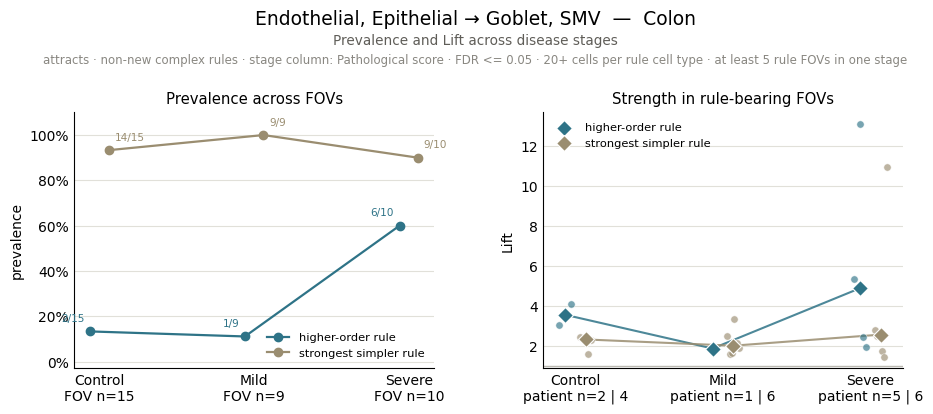

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_eligible_endothelial_epithelial_goblet_smv_fovs.png


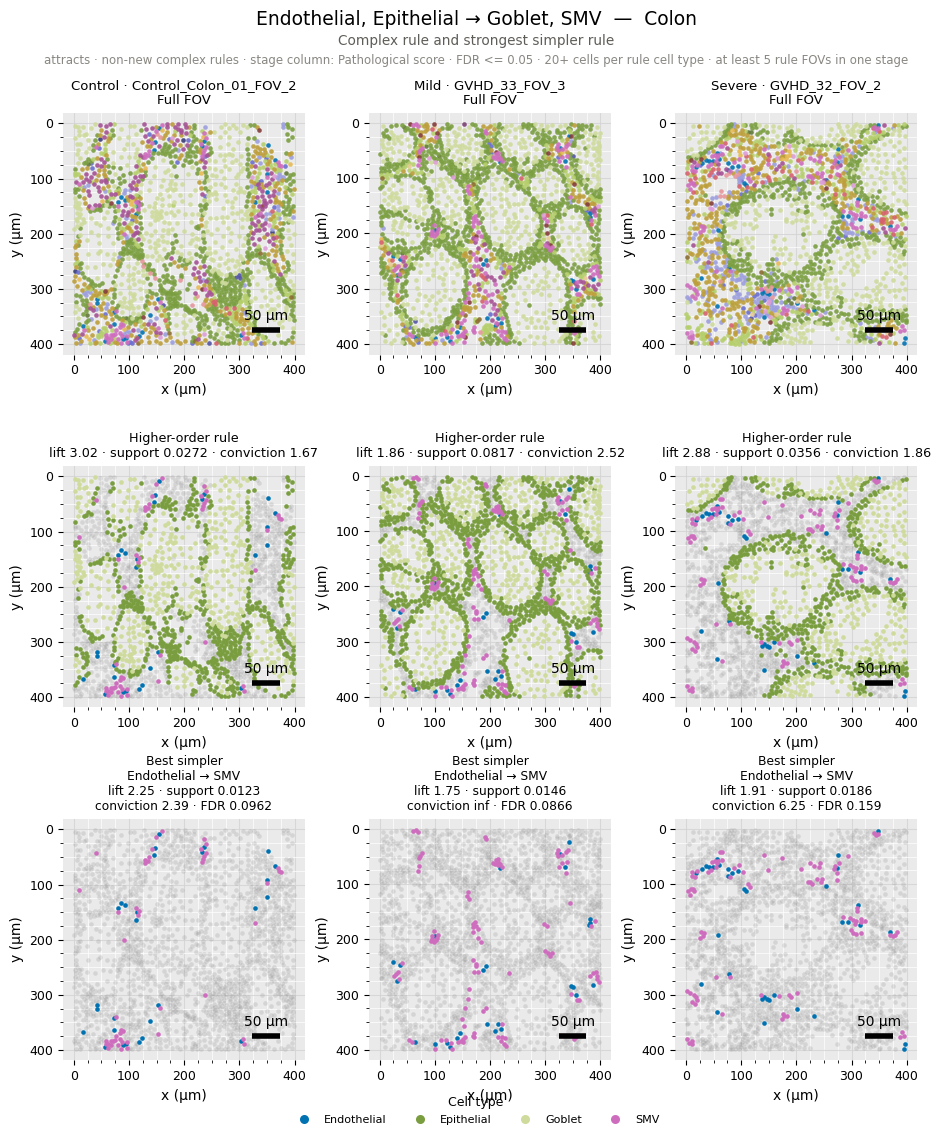

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_nonnew_goblet_macrophage_epithelial_plasma_availability.png


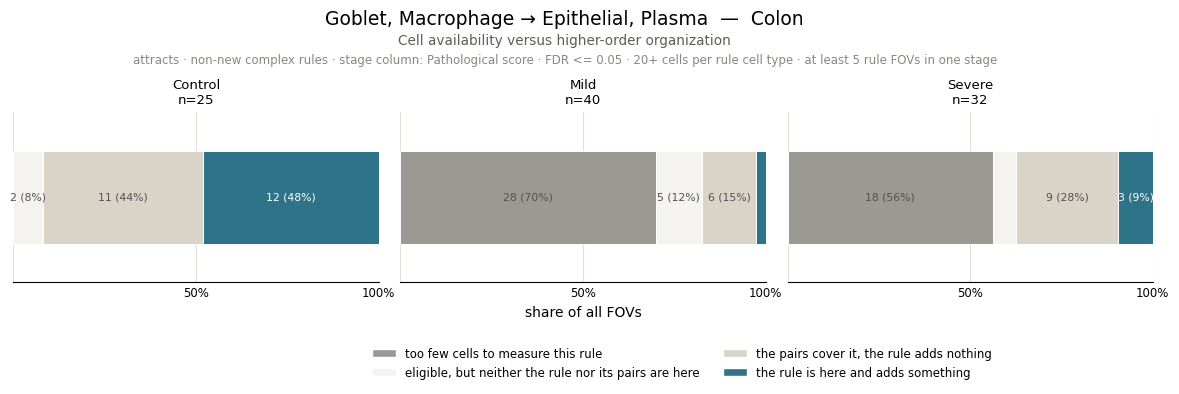

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_nonnew_eligible_goblet_macrophage_epithelial_plasma_strength.png


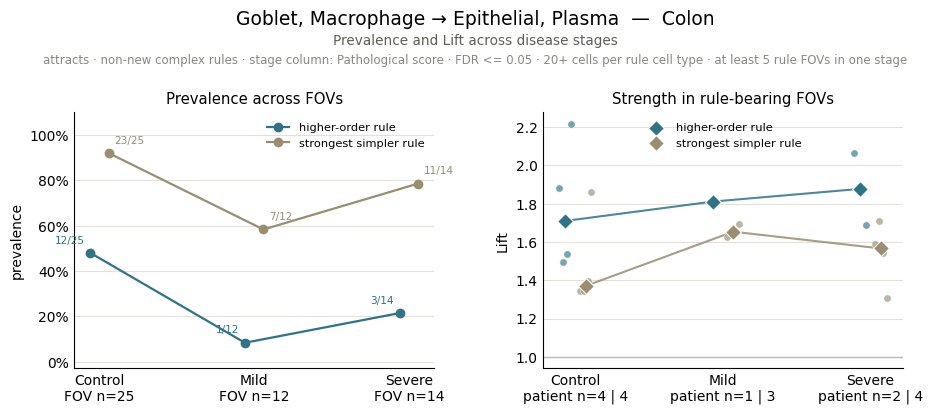

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_nonnew_eligible_goblet_macrophage_epithelial_plasma_fovs.png


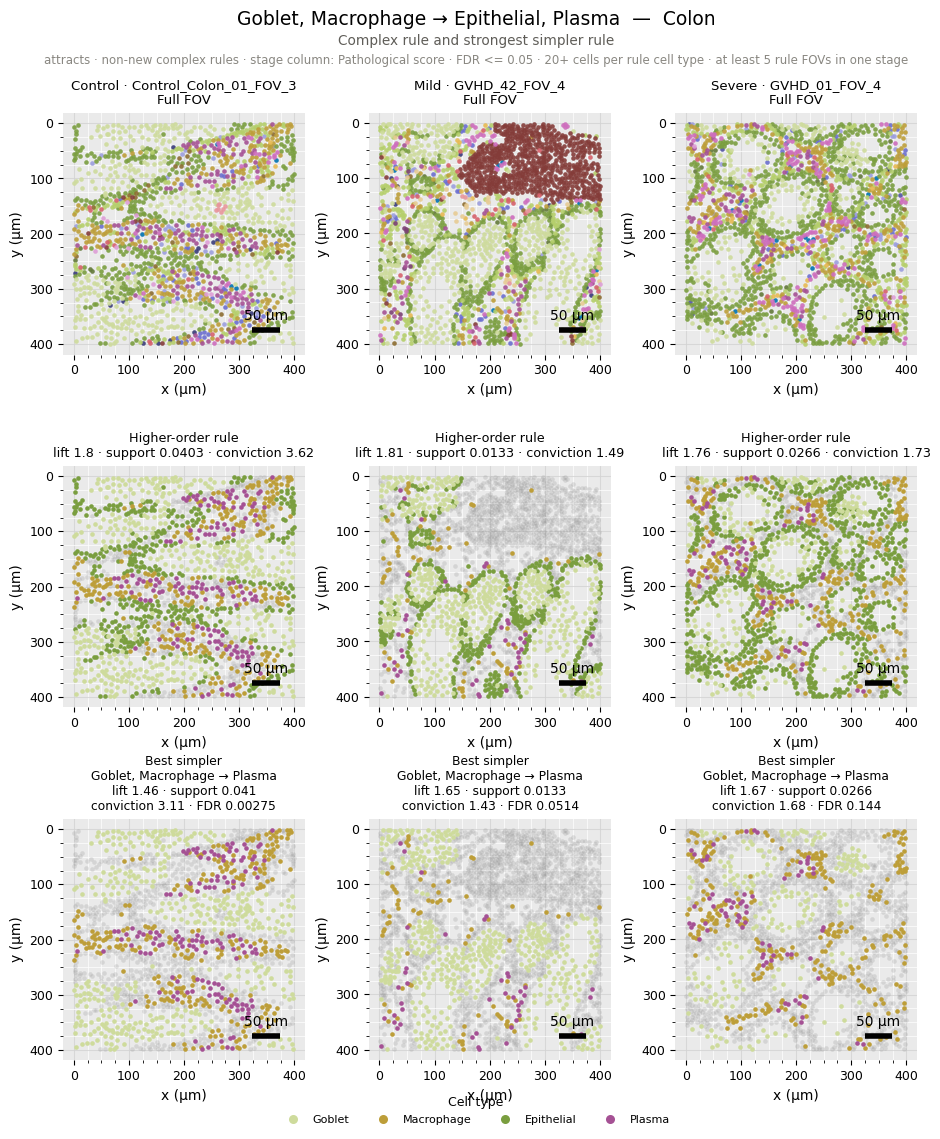

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_opposite_epithelial_neuron_goblet_macrophage_strength.png


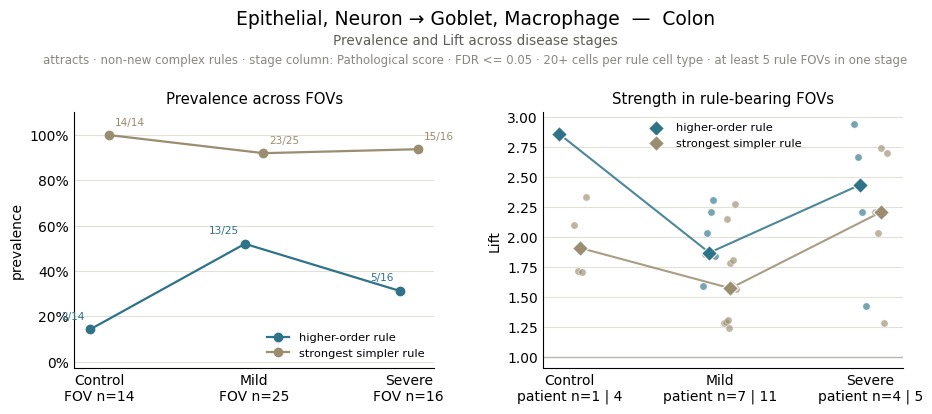

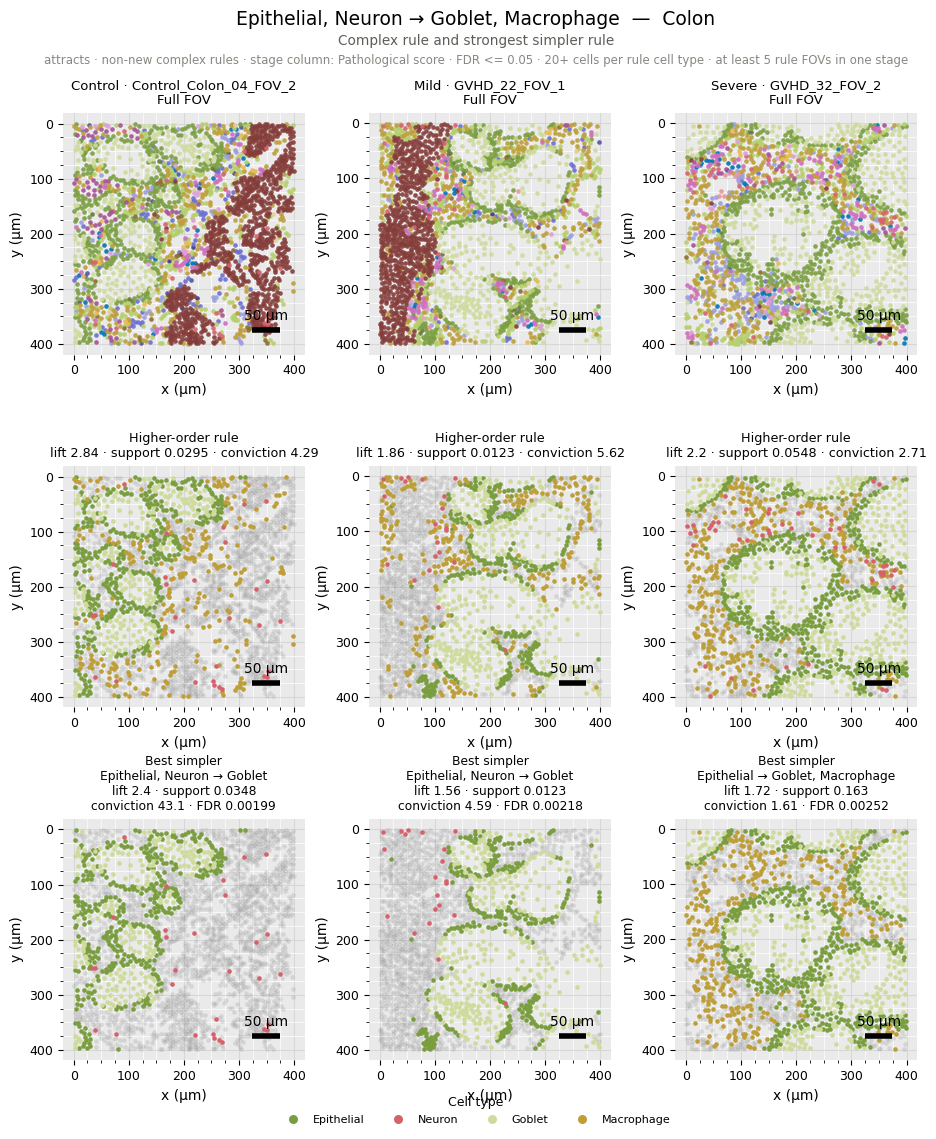

### Duodenum

,name,stage,complex prevalence,simpler prevalence
3003,"Macrophage, Paneth -> CD8T, Epithelial",Control,1 / 12 (8%),10 / 12 (83%)
3004,"Macrophage, Paneth -> CD8T, Epithelial",Mild,5 / 38 (13%),23 / 38 (61%)
3005,"Macrophage, Paneth -> CD8T, Epithelial",Severe,2 / 4 (50%),3 / 4 (75%)
4290,"Endothelial, Epithelial -> Goblet, Macrophage",Control,0 / 18 (0%),18 / 18 (100%)
4291,"Endothelial, Epithelial -> Goblet, Macrophage",Mild,8 / 54 (15%),50 / 54 (93%)
4292,"Endothelial, Epithelial -> Goblet, Macrophage",Severe,2 / 6 (33%),5 / 6 (83%)
7647,"Neuron, Paneth -> Epithelial, SMV",Control,0 / 10 (0%),8 / 10 (80%)
7648,"Neuron, Paneth -> Epithelial, SMV",Mild,6 / 58 (10%),45 / 58 (78%)
7649,"Neuron, Paneth -> Epithelial, SMV",Severe,2 / 6 (33%),5 / 6 (83%)
1062,"Epithelial, Plasma_CD38 -> Fibroblast, Goblet",Control,1 / 27 (4%),27 / 27 (100%)


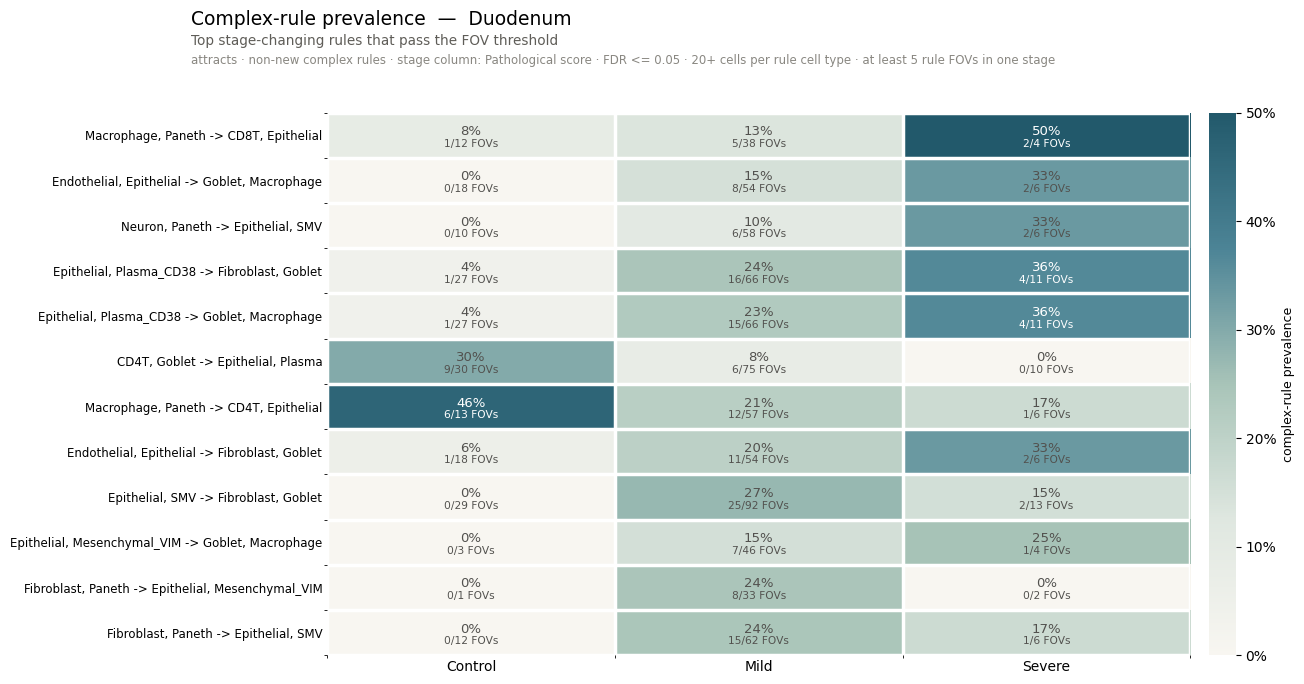

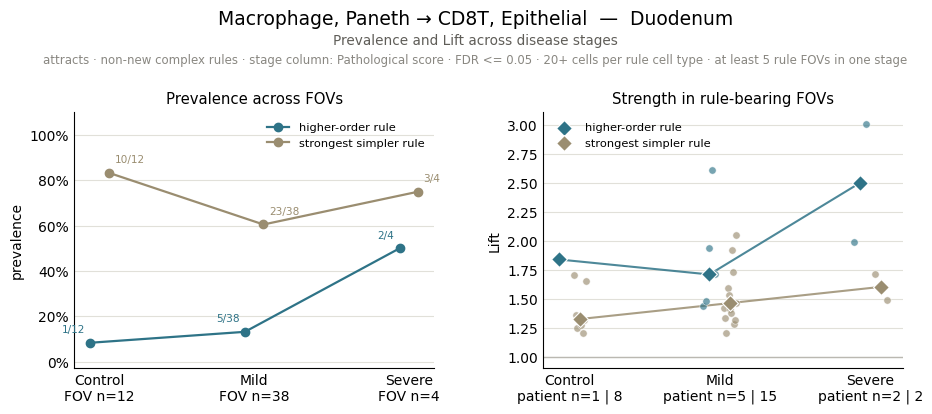

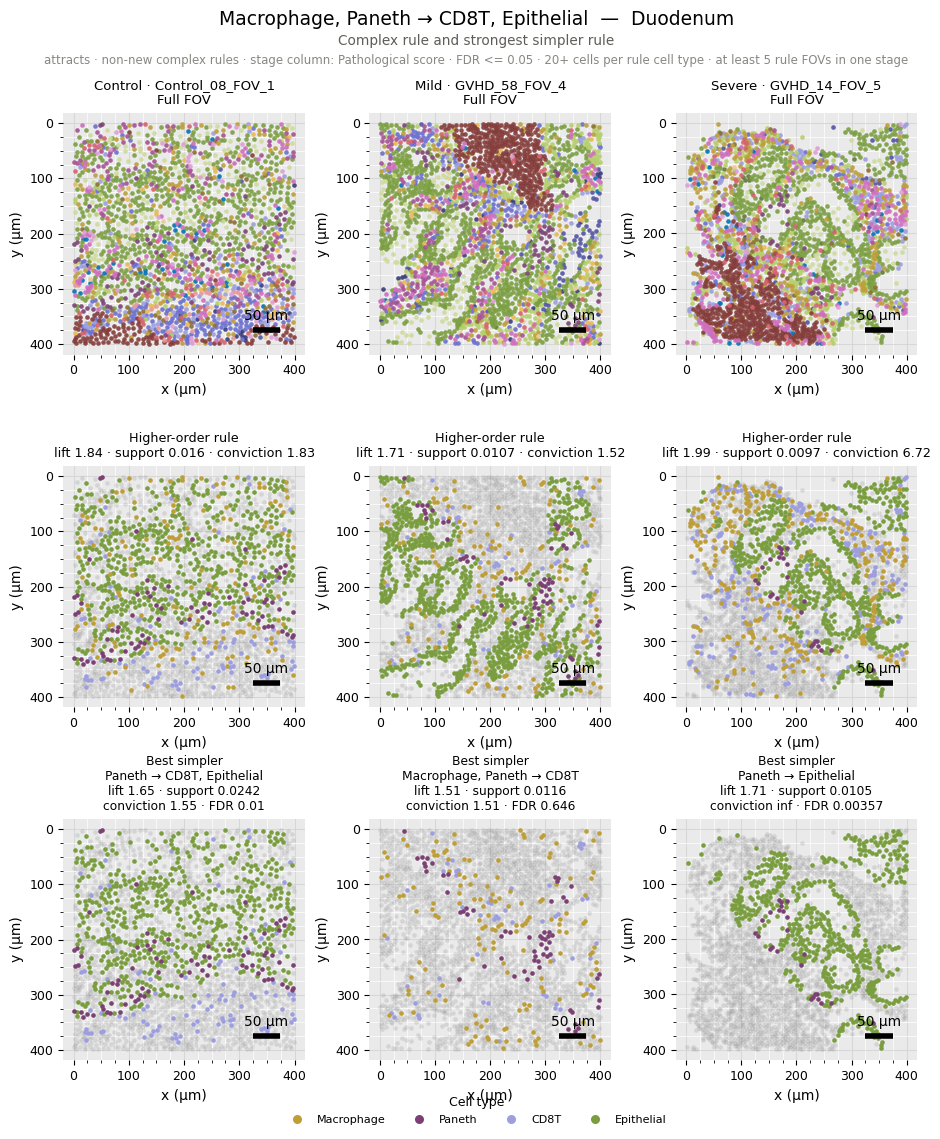

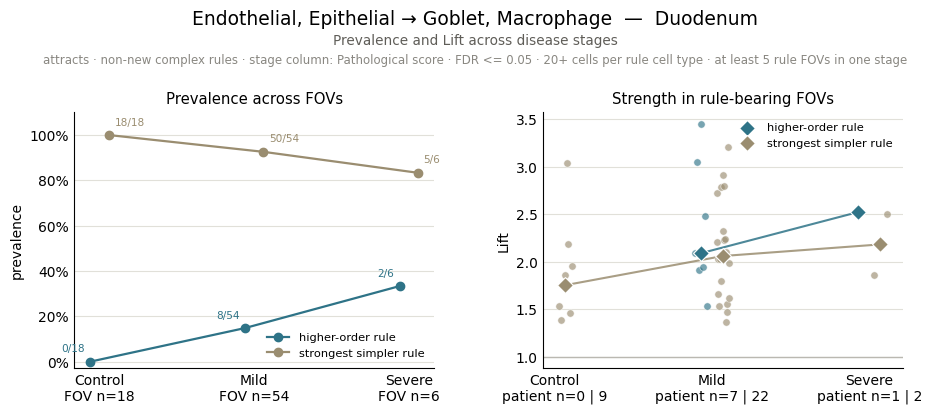

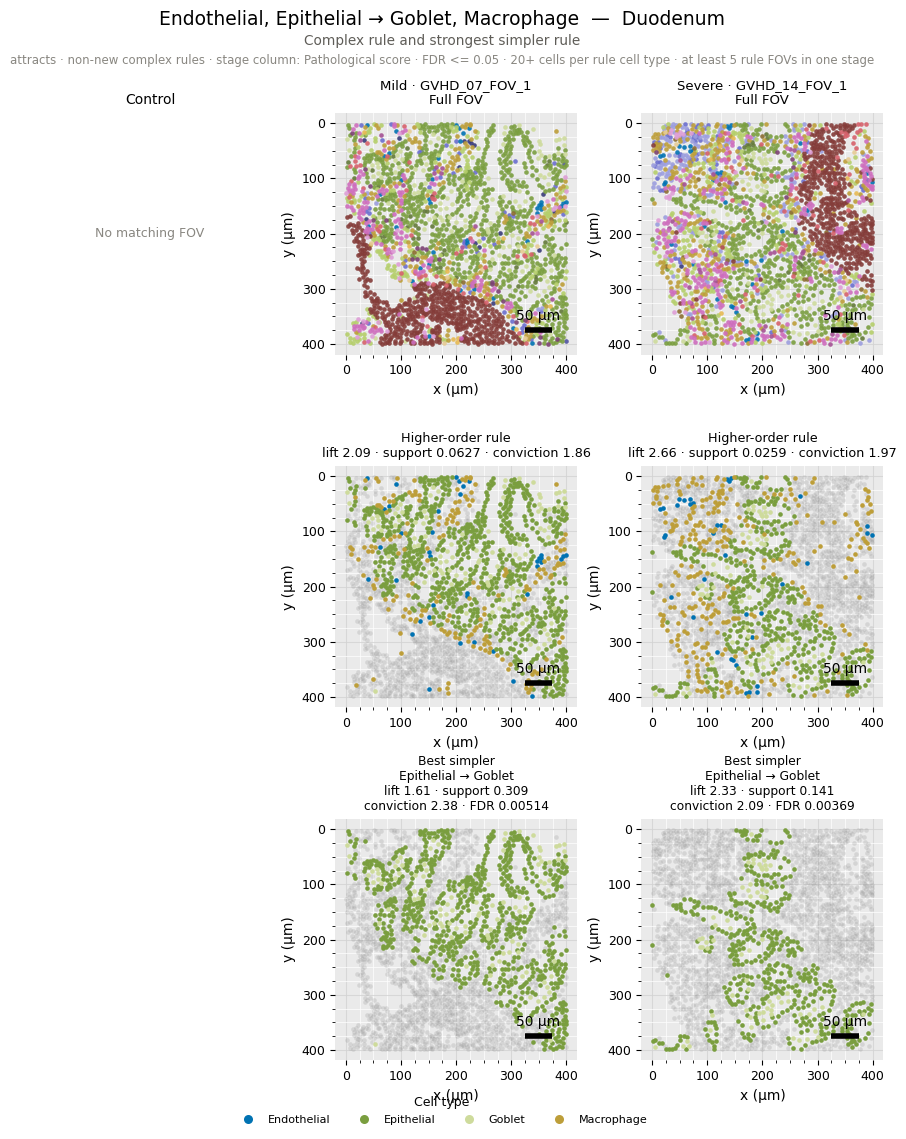

In [6]:
show_kind("attracts")


## Avoidances (negative spatial rules)


## Avoids

### Colon

,name,stage,complex prevalence,simpler prevalence
774,"Goblet -> CD4T, Mast",Control,14 / 14 (100%),14 / 14 (100%)
775,"Goblet -> CD4T, Mast",Mild,2 / 6 (33%),6 / 6 (100%)
776,"Goblet -> CD4T, Mast",Severe,0 / 3 (0%),1 / 3 (33%)
771,"Goblet -> Macrophage, Mast",Control,14 / 14 (100%),14 / 14 (100%)
772,"Goblet -> Macrophage, Mast",Mild,4 / 6 (67%),6 / 6 (100%)
773,"Goblet -> Macrophage, Mast",Severe,0 / 3 (0%),1 / 3 (33%)
339,"Goblet -> CD4T, Plasma_CD38",Control,6 / 9 (67%),9 / 9 (100%)
340,"Goblet -> CD4T, Plasma_CD38",Mild,2 / 2 (100%),2 / 2 (100%)
341,"Goblet -> CD4T, Plasma_CD38",Severe,0 / 4 (0%),3 / 4 (75%)
1155,"Goblet -> Macrophage, Plasma, Plasma_CD38",Control,5 / 9 (56%),9 / 9 (100%)


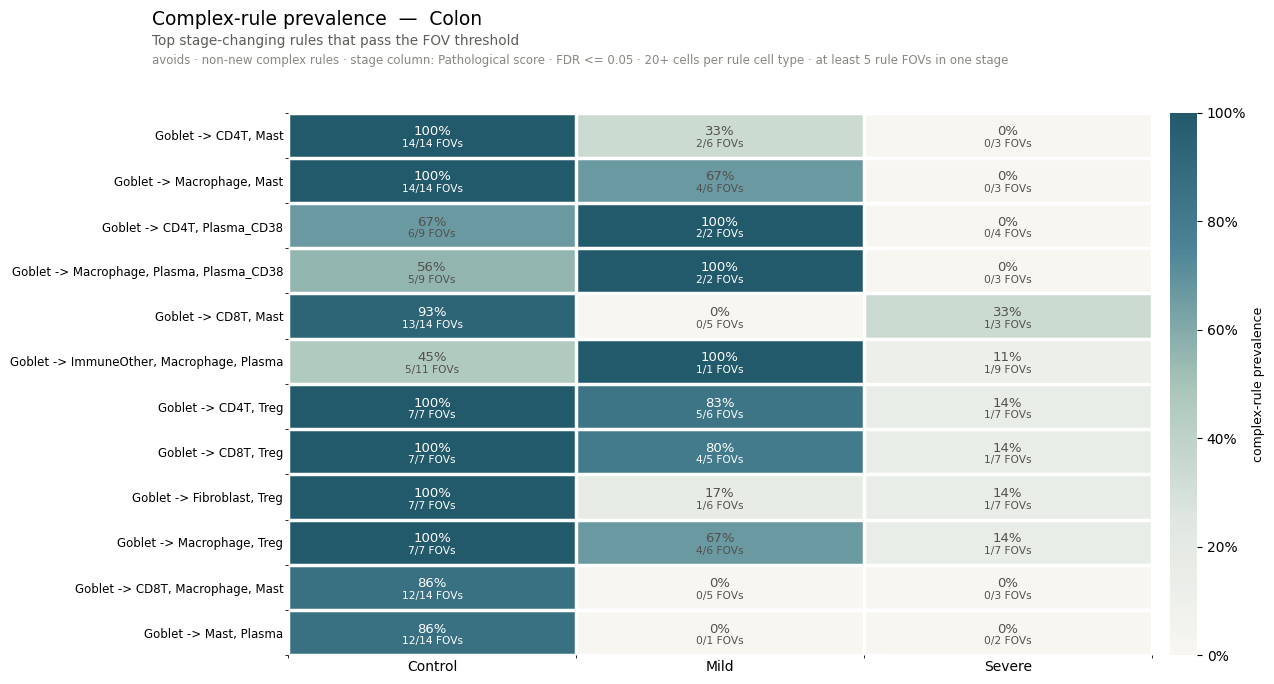

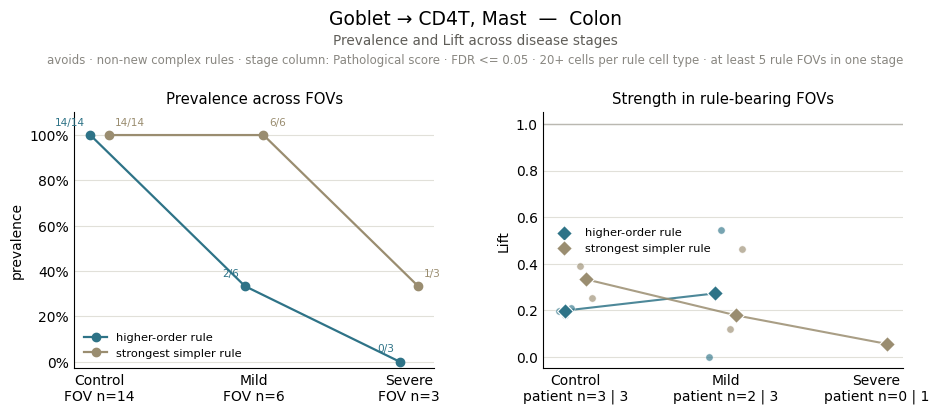

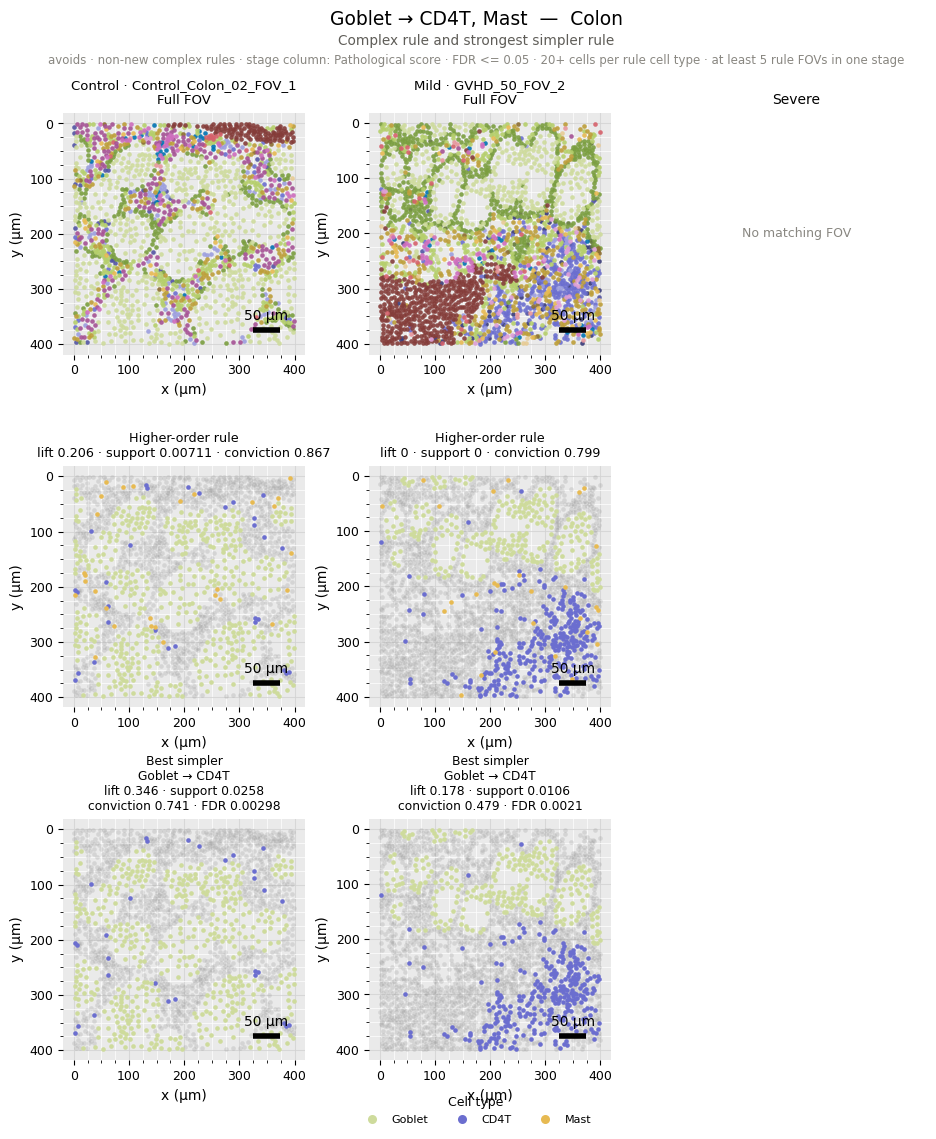

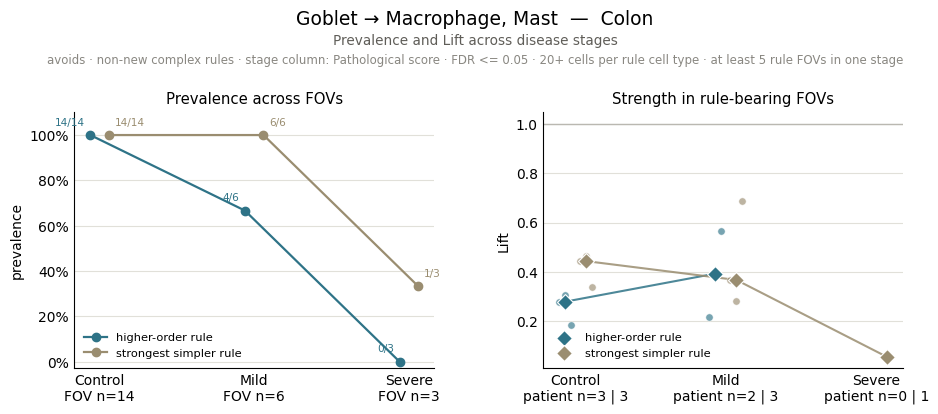

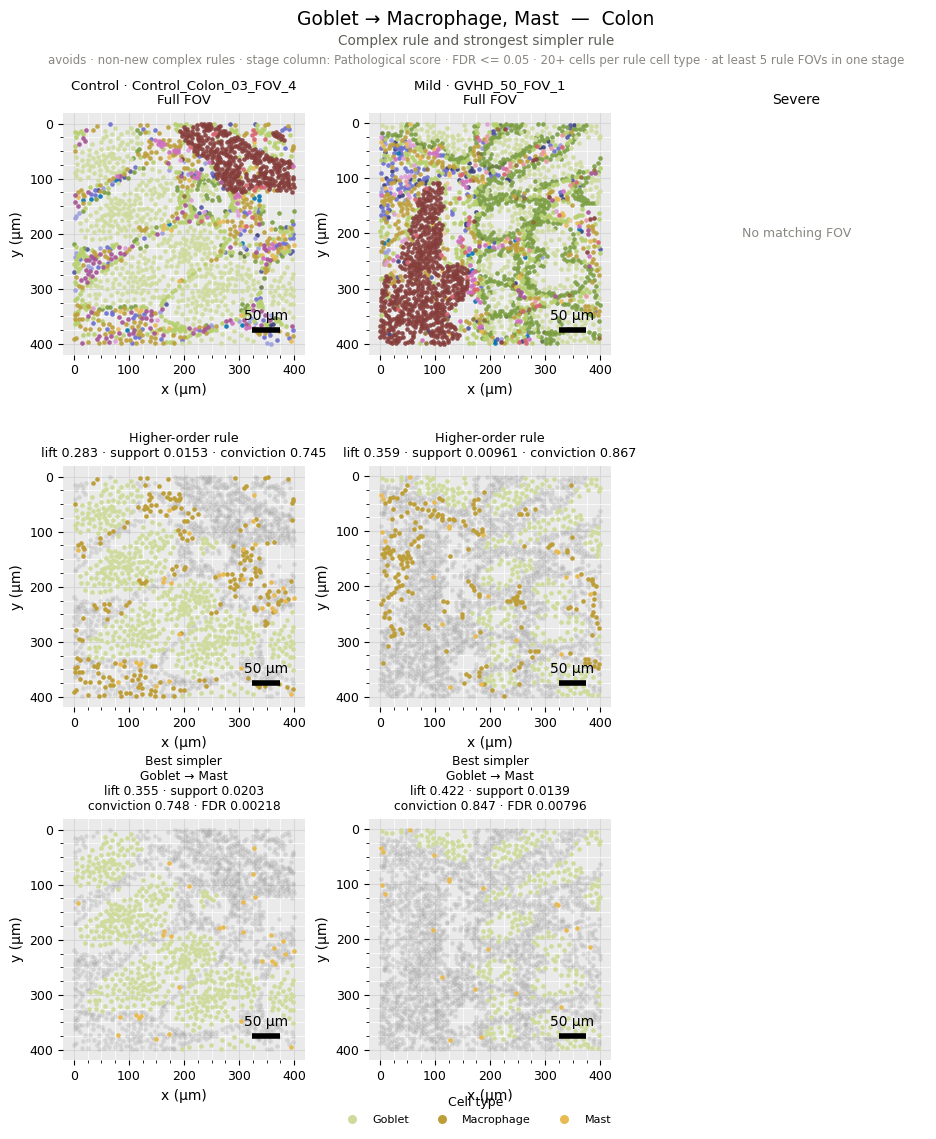

### Duodenum

,name,stage,complex prevalence,simpler prevalence
12993,"BrunnerGland -> Plasma, SMV",Control,0 / 6 (0%),3 / 6 (50%)
12994,"BrunnerGland -> Plasma, SMV",Mild,5 / 15 (33%),9 / 15 (60%)
12995,"BrunnerGland -> Plasma, SMV",Severe,1 / 1 (100%),1 / 1 (100%)
540,"Goblet -> CD8T, Macrophage",Control,9 / 28 (32%),25 / 28 (89%)
541,"Goblet -> CD8T, Macrophage",Mild,26 / 50 (52%),48 / 50 (96%)
542,"Goblet -> CD8T, Macrophage",Severe,7 / 8 (88%),8 / 8 (100%)
1476,"Muscle -> Plasma, SMV",Control,1 / 17 (6%),14 / 17 (82%)
1477,"Muscle -> Plasma, SMV",Mild,19 / 58 (33%),48 / 58 (83%)
1478,"Muscle -> Plasma, SMV",Severe,9 / 15 (60%),13 / 15 (87%)
177,"Epithelial, Goblet -> Muscle",Control,2 / 17 (12%),2 / 17 (12%)


saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_eligible_duodenum_avoids_overview.png


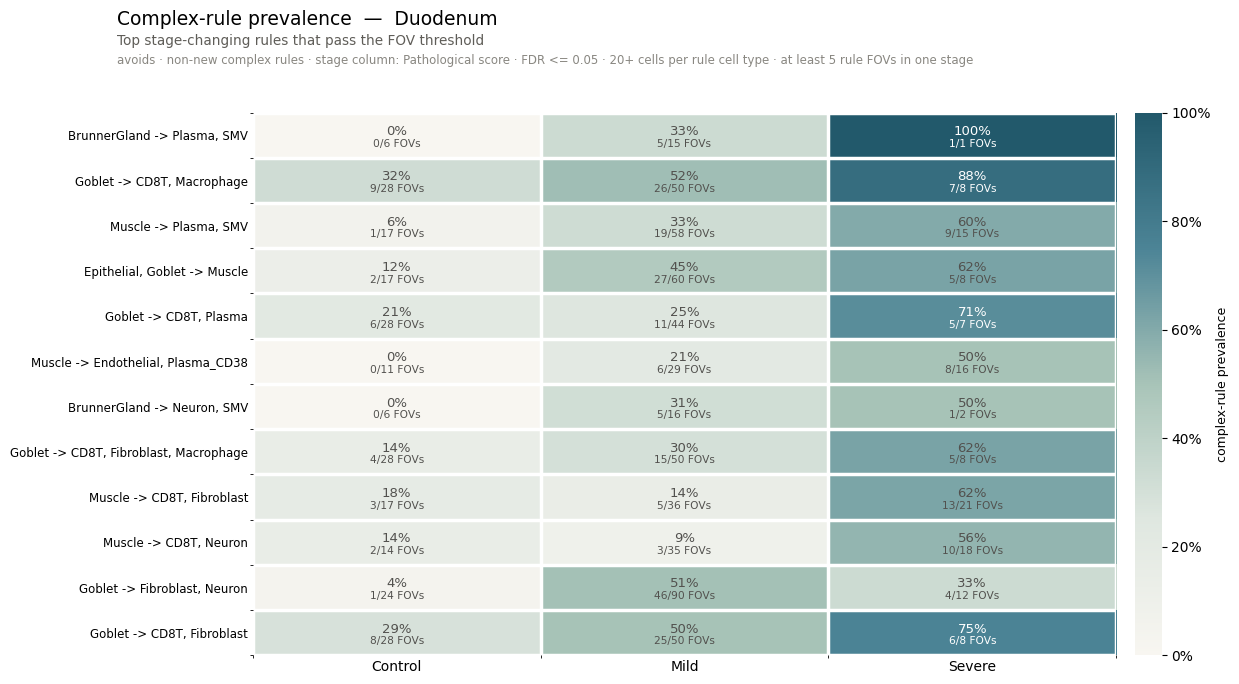

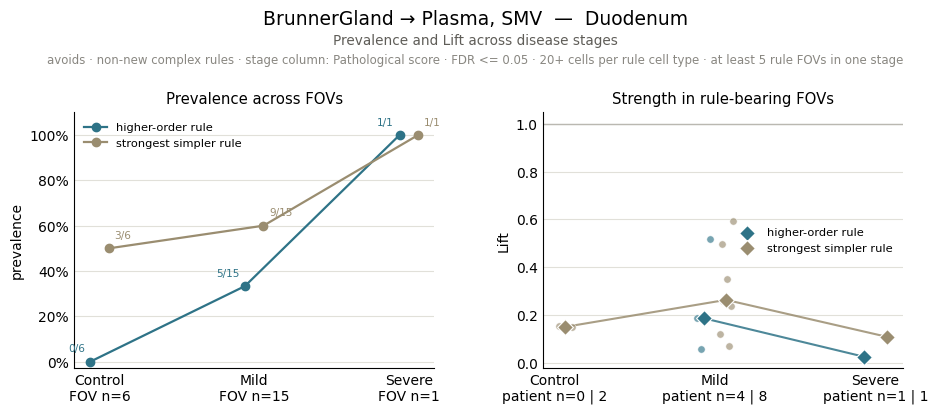

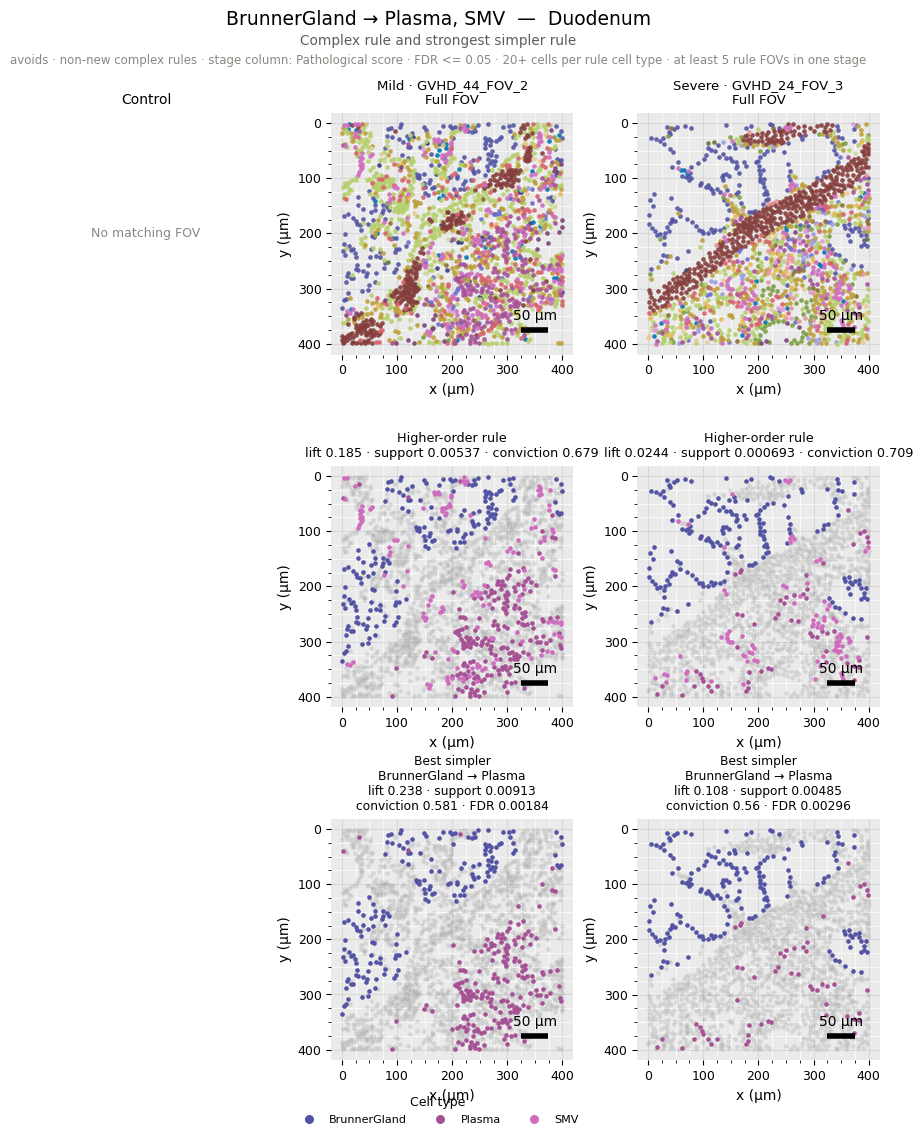

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_goblet_cd8t_macrophage_availability.png


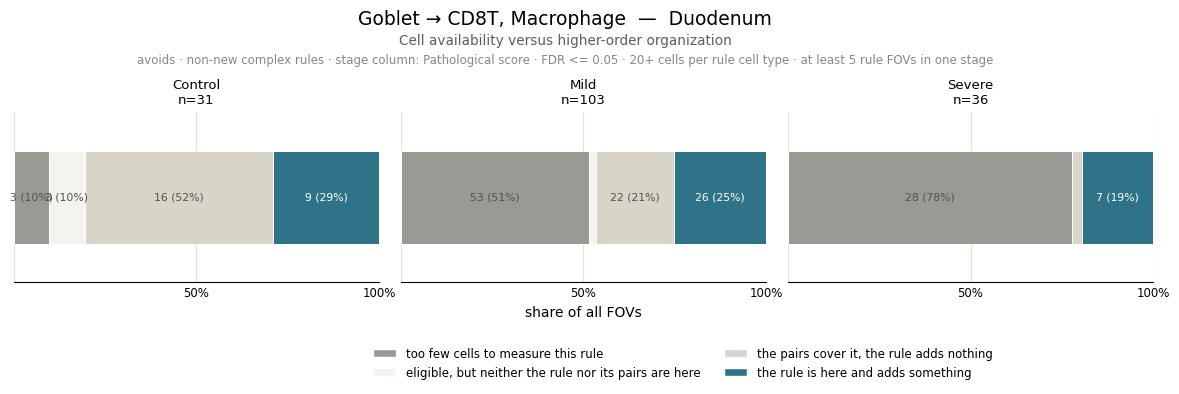

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_eligible_goblet_avoids_cd8t_macrophage_strength.png


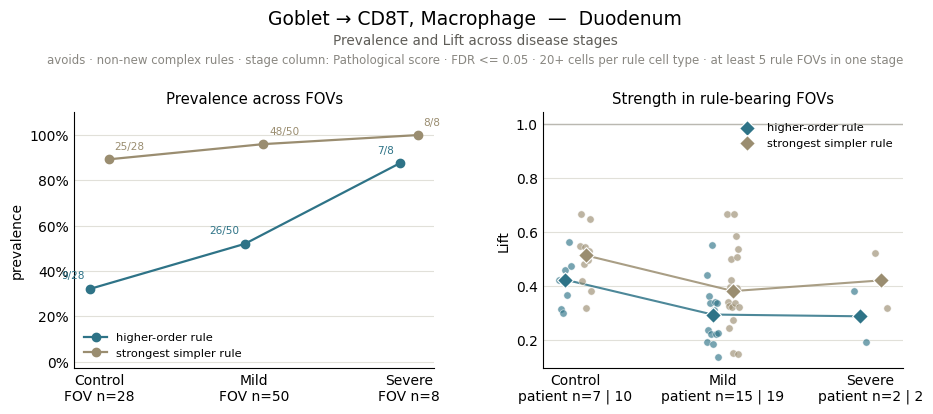

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_eligible_goblet_avoids_cd8t_macrophage_fovs.png


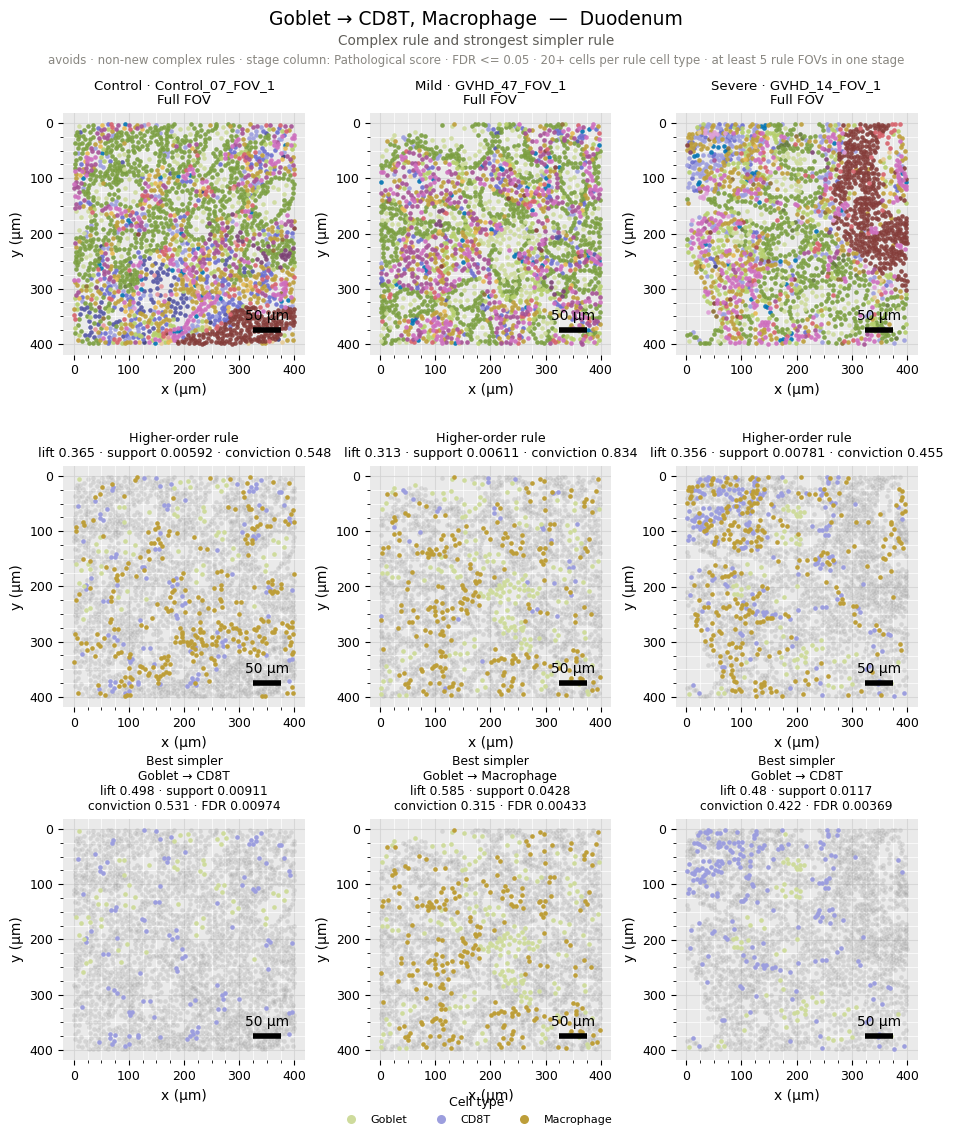

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_eligible_muscle_avoids_cd8t_fibroblast_strength.png


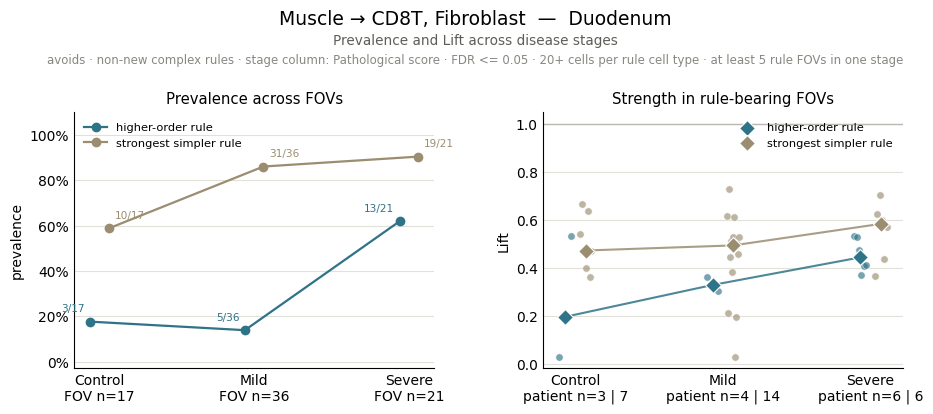

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_eligible_muscle_avoids_cd8t_fibroblast_fovs.png


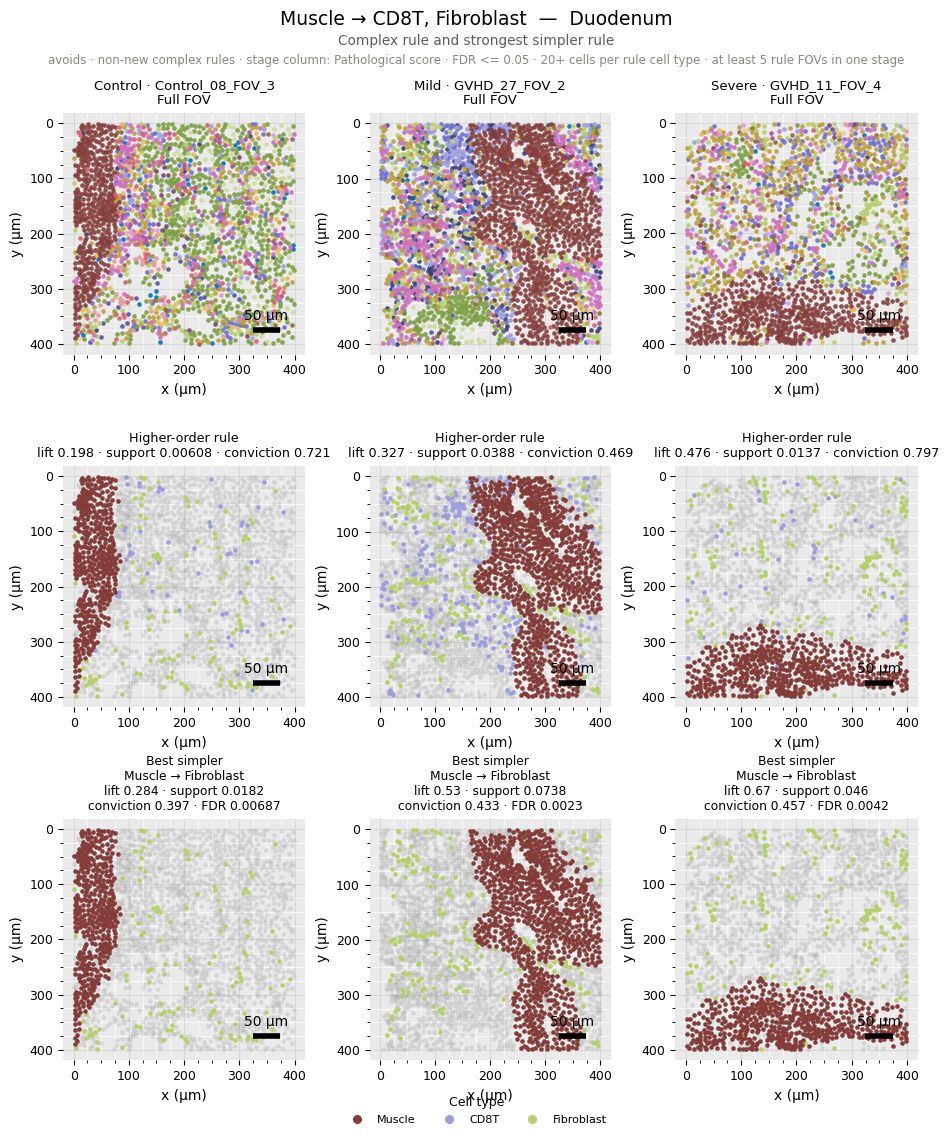

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_eligible_muscle_avoids_plasma_smv_strength.png


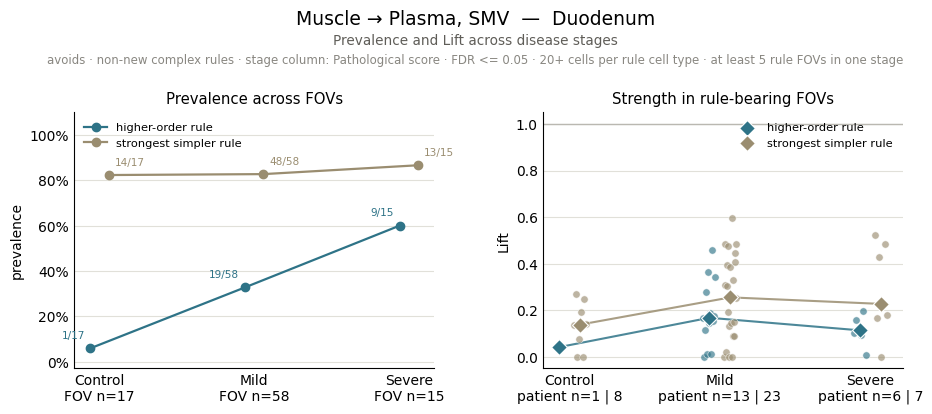

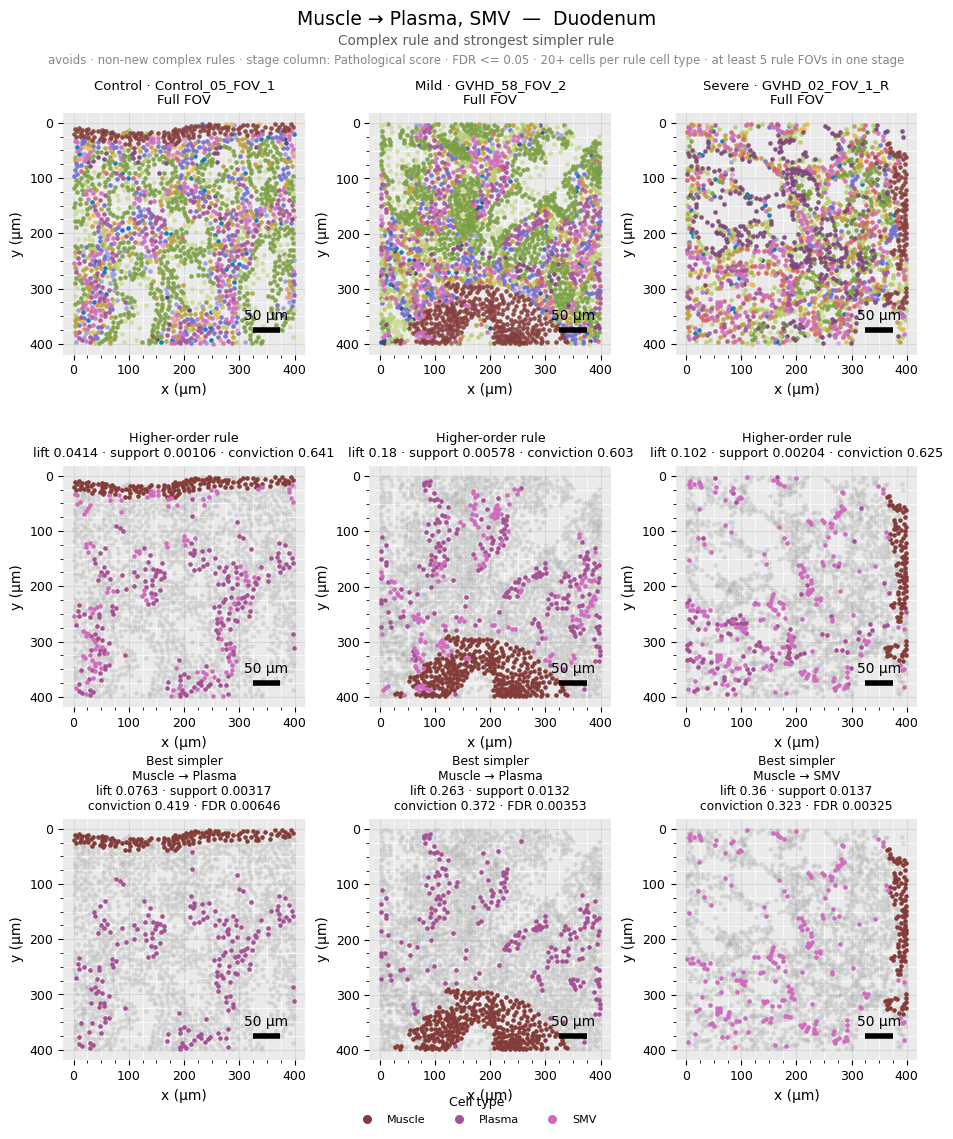

In [7]:
show_kind("avoids")
